# Operadores ineficaces - CallMeMaybe

**Objetivo general:**
_Desarrollar una metodología basada en datos para identificar operadores ineficaces dentro de la plataforma CallMeMaybe, definiendo ineficiencia como una combinación de alta tasa de llamadas perdidas, tiempos de espera prolongados y bajo volumen de llamadas salientes._
### Desarrollo

**Paso 1: Carga y análisis exploratorio de datos (EDA).**  
Se cargarán los datasets, se inspeccionará su estructura, valores faltantes y duplicados. Se realizará un análisis exploratorio inicial, que revelará la necesidad de **ponderar todas las métricas por `calls_count`** (número real de llamadas por registro). Tras esta corrección, se generarán visualizaciones y estadísticas que reflejen el verdadero volumen de llamadas, identificando distribuciones asimétricas y la conveniencia de tratar por separado los perfiles de operador (receptores, emisores, mixtos).

**Paso 2: Data wrangling — construcción de métricas de ineficiencia por operador.**  
Se derivarán las siguientes métricas agregadas por operador (siempre ponderadas por `calls_count`):
- Tiempo de espera promedio en llamadas entrantes externas (`avg_wait_time_incoming`).
- Tasa de llamadas perdidas en entrantes externas (`missed_rate_incoming`).
- Volumen total de llamadas salientes externas (`total_outgoing_calls`).
- Tasa de llamadas perdidas en salientes externas (`missed_rate_outgoing`).
- Proporción de llamadas salientes externas con duración cero (`zero_outgoing_ratio`).

Se generará un DataFrame `metrics` que contendrá estas métricas para todos los operadores.

**Paso 3: Sistema de ranking y clasificación de operadores.**  
A partir de la distribución observada en `metrics`, se definirán umbrales específicos (no necesariamente percentiles fijos) para cada métrica, buscando identificar comportamientos anómalos. Se asignará 1 punto por cada umbral superado. Los operadores con puntuación ≥ 3 serán considerados **ineficaces graves**. Se generarán listados y archivos CSV con los resultados.

**Paso 4: Comprobación estadística de los resultados.**  
Se formularán hipótesis para validar que el ranking efectivamente separa a los operadores ineficaces del resto y que existe relación entre ciertas métricas (pérdidas salientes y duración cero). Se aplicarán pruebas no paramétricas (Mann-Whitney U y correlación de Spearman) con un nivel de significación α = 0.05.

**Paso 5: Conclusiones y recomendaciones.**  
Se resumirán los hallazgos clave, se describirá el perfil del operador ineficaz y se ofrecerán recomendaciones concretas para la supervisión y gestión del equipo operativo, basadas en la evidencia estadística y el ranking obtenido.

## Paso 1, primera parte: Carga, exploración y limpieza

In [1]:
# Se cargan librerias necesarias para el análisis
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as st
import numpy as np

# Se cargan csv como DataFrame
operators = pd.read_csv('data/telecom_dataset_new.csv')
clients = pd.read_csv('data/telecom_clients.csv')

# Se explora composición y estructura de DFs
for name, df in {'operators':operators, 'clients':clients}.items():
    print(f'Datos de {name}')
    df.info()
    print()
    print(df.sample(3))
    print()
    print(f'Duplicados totales en {name}: {df.duplicated().sum()}')
    print()

Datos de operators
<class 'pandas.DataFrame'>
RangeIndex: 53902 entries, 0 to 53901
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   user_id              53902 non-null  int64  
 1   date                 53902 non-null  str    
 2   direction            53902 non-null  str    
 3   internal             53785 non-null  object 
 4   operator_id          45730 non-null  float64
 5   is_missed_call       53902 non-null  bool   
 6   calls_count          53902 non-null  int64  
 7   call_duration        53902 non-null  int64  
 8   total_call_duration  53902 non-null  int64  
dtypes: bool(1), float64(1), int64(4), object(1), str(2)
memory usage: 3.3+ MB

       user_id                       date direction internal  operator_id  \
9986    166660  2019-08-28 00:00:00+03:00       out    False     887802.0   
19029   166983  2019-10-08 00:00:00+03:00        in    False     901884.0   
13858   166803  2019-10

De este output se puede observar que hay varias columnas con un tipo de dato incorrecto:
- las columnas date y date_start no son datetime
- operators['internal'] tiene valores faltantes y está en object cuando deberia ser un booleano.
- operator_id tiene valores nulos, lo que implica que hay llamadas sin operador, lo que es un problema para calificar a los operadores. (tampoco es un número menor)
- la información técnica no informa sobre la unidad en que se mide, se asume que es en segundos. No se cambiará la unidad hasta la presentación de los datos, pues las métricas funcionan mejor en segundos.
- hay una gran cantidad de datos duplicados en operators

Por lo anterior, es necesario cambiar los tipos de datos, pero para hacerlo con internal y con operator_id, es necesario primero ver porqué faltan los datos y si estos pueden asignarse o deben eliminarse. 

Antes de explorar el origen de esas llamadas se eliminan los datos duplicados para ver si disminuye el número de nulos. 

In [2]:
operators = operators.drop_duplicates().reset_index(drop=True)
print('Información de operators sin duplicados')
operators.info()

Información de operators sin duplicados
<class 'pandas.DataFrame'>
RangeIndex: 49002 entries, 0 to 49001
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   user_id              49002 non-null  int64  
 1   date                 49002 non-null  str    
 2   direction            49002 non-null  str    
 3   internal             48892 non-null  object 
 4   operator_id          41546 non-null  float64
 5   is_missed_call       49002 non-null  bool   
 6   calls_count          49002 non-null  int64  
 7   call_duration        49002 non-null  int64  
 8   total_call_duration  49002 non-null  int64  
dtypes: bool(1), float64(1), int64(4), object(1), str(2)
memory usage: 3.0+ MB


Lo que se observa, una vez eliminado los duplicados es que el número de nulos no ha disminuido. 

Se procede a buscar la razón de los nulos en operator_id y en internal para averiguar que se necesita hacer con ellos. 

In [3]:
# se filtran las llamadas que no tienen operador asignado
sin_operador = operators[operators['operator_id'].isna()]

# Se imprime la proporción de llamadas pérdidas sin operador.
print("--- Llamadas sin ID de Operador ---")
print(f"Total de registros sin operador: {len(sin_operador)}")
print("\nDistribución de llamadas perdidas:")
print(sin_operador['is_missed_call'].value_counts(normalize=True))

--- Llamadas sin ID de Operador ---
Total de registros sin operador: 7456

Distribución de llamadas perdidas:
is_missed_call
True     0.984844
False    0.015156
Name: proportion, dtype: float64


Considerando que la gran mayoría son llamadas perdidas, muy probablemente no tienen operador porque fueron cortadas antes de asignar uno. Utilizarlas para analizar métricas sería injusto y contaminaría el análisis. Se eliminan.

In [4]:
# se eliminan las llamadas sin operator_id
operators_clean = operators.dropna(subset=['operator_id']).reset_index(drop=True)

operators_clean.info()

<class 'pandas.DataFrame'>
RangeIndex: 41546 entries, 0 to 41545
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   user_id              41546 non-null  int64  
 1   date                 41546 non-null  str    
 2   direction            41546 non-null  str    
 3   internal             41491 non-null  object 
 4   operator_id          41546 non-null  float64
 5   is_missed_call       41546 non-null  bool   
 6   calls_count          41546 non-null  int64  
 7   call_duration        41546 non-null  int64  
 8   total_call_duration  41546 non-null  int64  
dtypes: bool(1), float64(1), int64(4), object(1), str(2)
memory usage: 2.6+ MB


In [5]:
# Se revisa la dirección de las llamadas en null para explorar su procedencia

internal_null = operators_clean[operators_clean['internal'].isna()]
print("\n--- Nulos en columna 'internal' ---")
print(f"Cantidad de nulos: {len(internal_null)}")
print("\n¿A qué dirección pertenecen mayoritariamente?")
print(internal_null['direction'].value_counts())


--- Nulos en columna 'internal' ---
Cantidad de nulos: 55

¿A qué dirección pertenecen mayoritariamente?
direction
in    55
Name: count, dtype: int64


La mitad de llamadas con internal null fueron eliminadas en el filtro anterior, considerando que no se puede determinar correctamente si las restantes son llamadas internas o externas se decide eliminarlas para tener datos limpios.

In [6]:
# se eliminan los nulos de internal
operators_clean = operators_clean.dropna(subset=['internal']).reset_index(drop=True)

# se cambian los tipos de datos para el correcto análisis
operators_clean['operator_id'] = operators_clean['operator_id'].astype(int).astype('category')
operators_clean['user_id'] = operators_clean['user_id'].astype(int).astype('category')
operators_clean['direction'] = operators_clean['direction'].astype('category')
operators_clean['internal'] = operators_clean['internal'].astype(bool)
operators_clean['date'] = pd.to_datetime(operators_clean['date'])

clients['date_start'] = pd.to_datetime(clients['date_start'])
clients['user_id'] = clients['user_id'].astype('category')
clients['tariff_plan'] = clients['tariff_plan'].astype('category')

# se imprime la información de los DF limpios
operators_clean.info()
print()
clients.info()

<class 'pandas.DataFrame'>
RangeIndex: 41491 entries, 0 to 41490
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype                    
---  ------               --------------  -----                    
 0   user_id              41491 non-null  category                 
 1   date                 41491 non-null  datetime64[us, UTC+03:00]
 2   direction            41491 non-null  category                 
 3   internal             41491 non-null  bool                     
 4   operator_id          41491 non-null  category                 
 5   is_missed_call       41491 non-null  bool                     
 6   calls_count          41491 non-null  int64                    
 7   call_duration        41491 non-null  int64                    
 8   total_call_duration  41491 non-null  int64                    
dtypes: bool(2), category(3), datetime64[us, UTC+03:00](1), int64(3)
memory usage: 1.6 MB

<class 'pandas.DataFrame'>
RangeIndex: 732 entries, 0 to 731
Dat

Se comprobó que los DF están limpios y con el tipo de dato correcto. Siguiendo una buena práctica se crean copias de archivos csv limpios.

In [7]:
# Exportar el DataFrame limpio a la carpeta de datos procesados
operators_clean.to_csv('data/processed/operators_cleaned.csv', index=False)

# También exportamos el de clientes ya que le cambiamos el formato de fecha
clients.to_csv('data/processed/clients_cleaned.csv', index=False)

## Paso 1, segunda parte: EDA

Teniendo los datos limpios se continua con la exploración de los datos. 

Primero se describe el dataset de forma general y después separado por operador, de esta manera se tiene una visión global y particular de los datos.

In [8]:
# se describe el DF de operadores para entender su composición
print("--- Descripción de operadores ---")  
print(operators_clean.describe(include='all'))
print("\n--- Descropción de clientes ---")
print(clients.describe(include='all'))  

--- Descripción de operadores ---
         user_id                              date direction internal  \
count    41491.0                             41491     41491    41491   
unique     290.0                               NaN         2        2   
top     168187.0                               NaN       out    False   
freq      2267.0                               NaN     28813    36161   
mean         NaN  2019-10-23 15:58:20.739919+03:00       NaN      NaN   
min          NaN         2019-08-02 00:00:00+03:00       NaN      NaN   
25%          NaN         2019-10-06 00:00:00+03:00       NaN      NaN   
50%          NaN         2019-10-28 00:00:00+03:00       NaN      NaN   
75%          NaN         2019-11-14 00:00:00+03:00       NaN      NaN   
max          NaN         2019-11-28 00:00:00+03:00       NaN      NaN   
std          NaN                               NaN       NaN      NaN   

        operator_id is_missed_call   calls_count  call_duration  \
count       41491.0   

### Sobre clients
En esta primera descripción se observa que el Dataset clients operators no tienen una unión directa, pues el número de user_id es distinto. Considerando que los datos de CLients no son necesarios, de momento se dejará de lado en el EDA. Si posteriormente se requiere se volverá a él.

### Sobre operators
- Tenemos un rango de análisis de 2019-08-02 al 2019-11-28, lo que ayuda a comprender mejor el tiempo con el que se trabaja para considerar los rangos de eficiencia.
- Se observa que hay más llamadas salientes que entrantes un ~3/4 del totla, lo que implica que es necesario poner especial enfasis en las llamadas salientes para la métrica de ineficiencia.
- La mayoria de llamadas son externas ~7/8, por lo que hay tener en menor estima el flujo de llamadas internas para el score.
- Sobre la duración de las llamadas, se observa que hay varios valores en 0, incluso el percentil 25 tiene 0, lo que es sospechoso. Es necesario investigar para saber porque no se estan tomando esas llamadas.
- La duración media de la llamada es de 1010 segundos (16.8 min.) lo que no deja bien a ese 25% de operadores, ya estan lejos de la media.
- hay un desbalance importante en el conteo de llamadas, hay operadores con una sola en un periodo de 4 meses, es necesario encontrarlos e investigar qué pasa. ¿Por qué hay operadores con solo 1 llamada en 4 meses? ¿Son nuevos o inactivos?
- El promedio son 16 llamadas, es necesario averiguar también al respecto de esos operadores con números extremadamente átipicos tanto bajos como altos.
- Estos datos van dando indicios sobre cómo hay que colocar los parametros de ineficiencia pues si el 25 percentil de total_call es 67  segundos hay algo extraño.

Siguientes pasos:
- Se crean histogramas para observar la distribución de las llamadas
- se crean gráficos de barras para observar directamente la diferencia entre entrantes y salientes
- se muestra proporción de llamadas perdidas respecto al total
- Se muestra un boxplot con la distribucion de llamadas por operador.

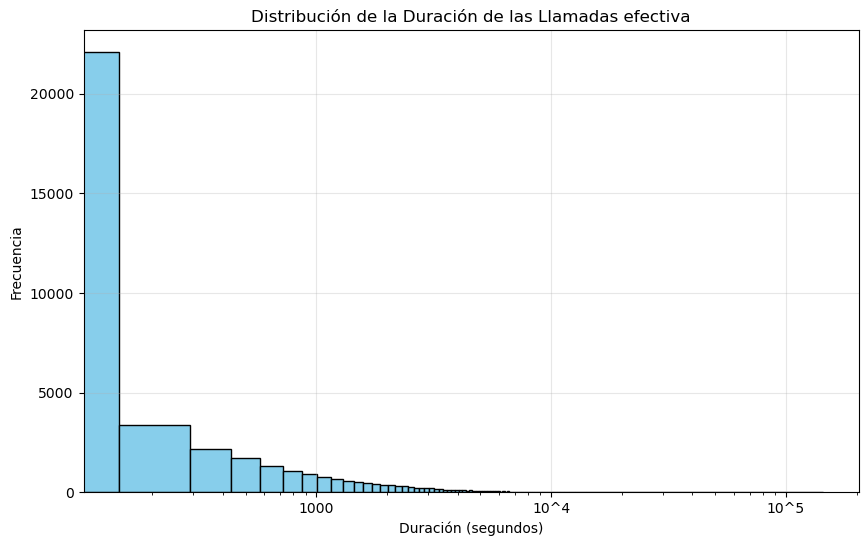

In [9]:
# se crean histogramas para visualizar la distribución de la dureación de las llamadas
plt.figure(figsize=(10, 6))
plt.hist(operators_clean['call_duration'], bins=1000, color='skyblue', edgecolor='black')
plt.title('Distribución de la Duración de las Llamadas efectiva')
plt.xlabel('Duración (segundos)')  
plt.ylabel('Frecuencia')
plt.grid(True, alpha=0.3)
plt.xscale('log')
plt.xticks([1000, 10000, 100000], ['1000', '10^4', '10^5'])
plt.show()

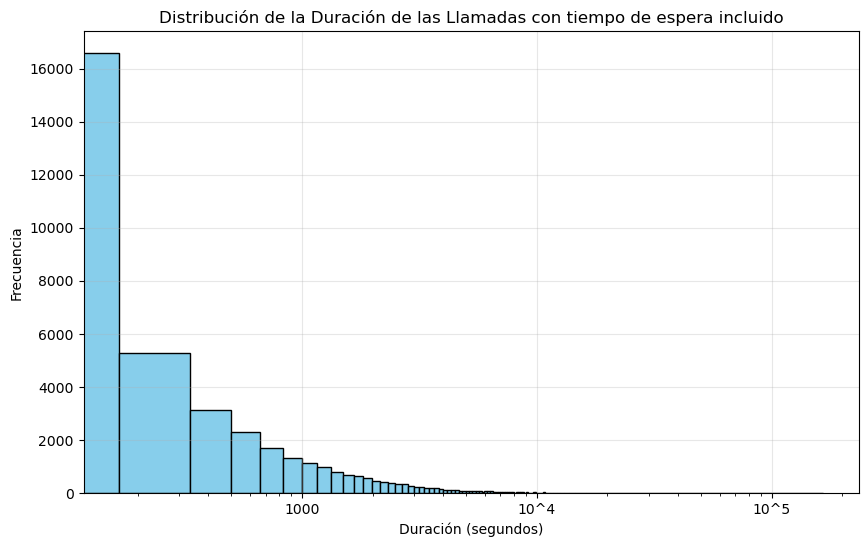

In [10]:
plt.figure(figsize=(10, 6))
plt.hist(operators_clean['total_call_duration'], bins=1000, color='skyblue', edgecolor='black')
plt.title('Distribución de la Duración de las Llamadas con tiempo de espera incluido')
plt.xlabel('Duración (segundos)')  
plt.ylabel('Frecuencia')
plt.grid(True, alpha=0.3)
plt.xscale('log')
plt.xticks([1000, 10000, 100000], ['1000', '10^4', '10^5'])
plt.show()

Lo que se observa con estos gráficos de la distribución general de las llamadas efectivas y las llamadas con tiempo de espera, es que la mayoría de los registros se concentran en rangos bajos, por debajo de 1.000 segundos, algo que ya sabiamos por las estadisticas descriptivas. Sin embargo, con estos gráficos se refuerzan las primeras hipótesis, hay datos que sesgan la distribución ya que es fuertemente asimétrica y tiene una cola larga hacia los valores más altos(por lo que tuvo que usarse una escala logarítmica.)

Se continua con el análisis. 

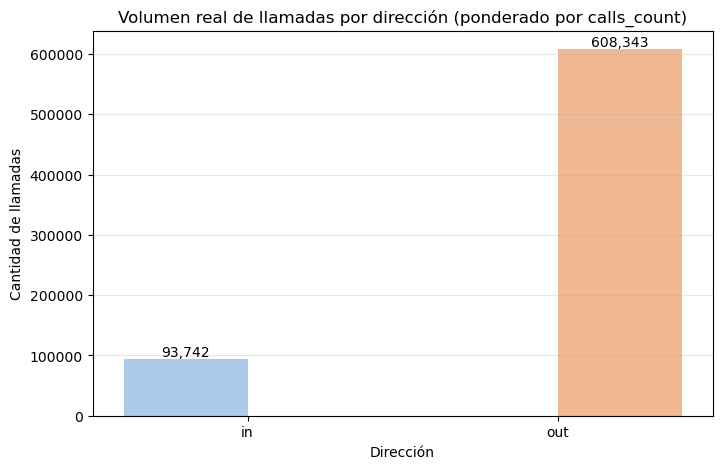

86.65% de las llamadas son salientes y 13.35% son entrantes.
Sin ponderar: 69.44% salientes, 30.56% entrantes


In [11]:
# Agrupar y sumar calls_count por dirección
volumen_dir = operators_clean.groupby('direction')['calls_count'].sum().reset_index()

plt.figure(figsize=(8, 5))
ax = sns.barplot(data=volumen_dir, x='direction', y='calls_count', hue='direction', palette='pastel', legend=False)

for p in ax.patches:
    height = p.get_height()
    ax.text(p.get_x() + p.get_width() / 2, height + 20, f'{int(height):,}',
            ha='center', va='bottom')

ax.set_title('Volumen real de llamadas por dirección (ponderado por calls_count)')
ax.set_xlabel('Dirección')
ax.set_ylabel('Cantidad de llamadas')
plt.grid(axis='y', alpha=0.3)
plt.show()

# Proporciones reales
total_llamadas = volumen_dir['calls_count'].sum()
prop_out = (volumen_dir[volumen_dir['direction']=='out']['calls_count'].values[0] / total_llamadas) * 100
prop_in = (volumen_dir[volumen_dir['direction']=='in']['calls_count'].values[0] / total_llamadas) * 100
print(f"{prop_out:.2f}% de las llamadas son salientes y {prop_in:.2f}% son entrantes.")

# Se muestran los resultados sin ponderar para comparar
print(f"Sin ponderar: {operators_clean['direction'].value_counts(normalize=True)['out']*100:.2f}% salientes, {operators_clean['direction'].value_counts(normalize=True)['in']*100:.2f}% entrantes")

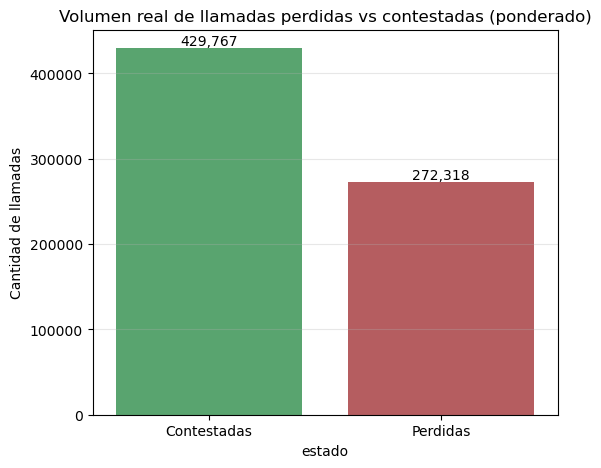

61.21% de las llamadas son contestadas y 38.79% son perdidas.
Sin ponderar: 66.00% contestadas, 34.00% perdidas


In [12]:
# Agrupar por is_missed_call sumando calls_count
volumen_perdidas = operators_clean.groupby('is_missed_call')['calls_count'].sum().reset_index()
# Renombrar para claridad
volumen_perdidas['estado'] = volumen_perdidas['is_missed_call'].map({True: 'Perdidas', False: 'Contestadas'})

plt.figure(figsize=(6, 5))
ax = sns.barplot(data=volumen_perdidas, x='estado', y='calls_count', hue='estado', palette=['#4CB06A', '#C44E52'], legend=False)

for p in ax.patches:
    height = p.get_height()
    ax.text(p.get_x() + p.get_width() / 2, height + 50, f'{int(height):,}',
            ha='center', va='bottom')

plt.title('Volumen real de llamadas perdidas vs contestadas (ponderado)')
plt.ylabel('Cantidad de llamadas')
plt.grid(axis='y', alpha=0.3)
plt.show()

total = volumen_perdidas['calls_count'].sum()
contestadas = volumen_perdidas[volumen_perdidas['is_missed_call']==False]['calls_count'].values[0]
perdidas = volumen_perdidas[volumen_perdidas['is_missed_call']==True]['calls_count'].values[0]
print(f"{contestadas/total*100:.2f}% de las llamadas son contestadas y {perdidas/total*100:.2f}% son perdidas.")

# se crea proporcion sin ponderar para comparar
missed_prop = operators_clean['is_missed_call'].value_counts(normalize=True) * 100
print(f"Sin ponderar: {missed_prop[False]:.2f}% contestadas, {missed_prop[True]:.2f}% perdidas")

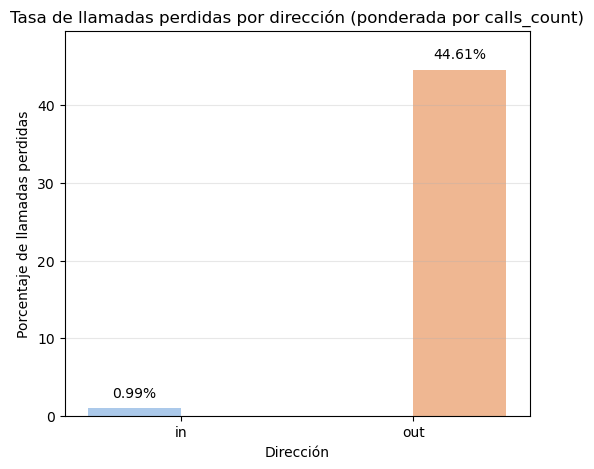

Sin ponderar: out: 46.59% perdidas, in: 5.40% perdidas


In [13]:
# Calcular total de llamadas y total de perdidas por dirección (ponderado)
perdidas_por_dir = operators_clean.groupby('direction').apply(
    lambda x: (x['is_missed_call'] * x['calls_count']).sum() / x['calls_count'].sum()
).reset_index(name='tasa_perdidas')
perdidas_por_dir['tasa_perdidas'] = perdidas_por_dir['tasa_perdidas'] * 100

plt.figure(figsize=(6, 5))
ax = sns.barplot(data=perdidas_por_dir, x='direction', y='tasa_perdidas', hue='direction', palette='pastel', legend=False)

for p in ax.patches:
    height = p.get_height()
    ax.text(p.get_x() + p.get_width() / 2, height + 1, f'{height:.2f}%',
            ha='center', va='bottom')

ax.set_title('Tasa de llamadas perdidas por dirección (ponderada por calls_count)')
ax.set_xlabel('Dirección')
ax.set_ylabel('Porcentaje de llamadas perdidas')
plt.grid(axis='y', alpha=0.3)
plt.ylim(0, max(perdidas_por_dir['tasa_perdidas']) + 5)
plt.show()

# proporción sin ponderar para comparar
sin_pond = operators_clean.groupby('direction')['is_missed_call'].mean() * 100
print(f"Sin ponderar: out: {sin_pond['out']:.2f}% perdidas, in: {sin_pond['in']:.2f}% perdidas")


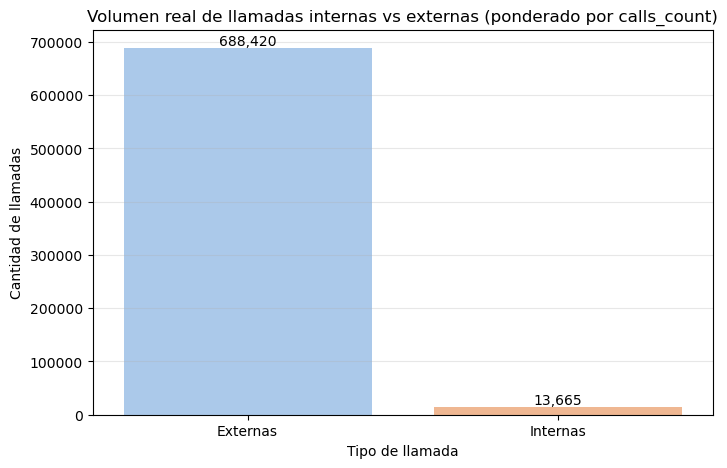

1.95% de las llamadas son internas y 98.05% son externas.
Sin ponderar: internas: 12.85%, externas: 87.15%


In [14]:
volumen_int = operators_clean.groupby('internal')['calls_count'].sum().reset_index()
volumen_int['tipo'] = volumen_int['internal'].map({True: 'Internas', False: 'Externas'})

plt.figure(figsize=(8, 5))
ax = sns.barplot(data=volumen_int, x='tipo', y='calls_count', hue='tipo', palette='pastel', legend=False)

for p in ax.patches:
    height = p.get_height()
    ax.text(p.get_x() + p.get_width() / 2, height + 20, f'{int(height):,}',
            ha='center', va='bottom')

ax.set_title('Volumen real de llamadas internas vs externas (ponderado por calls_count)')
ax.set_xlabel('Tipo de llamada')
ax.set_ylabel('Cantidad de llamadas')
plt.grid(axis='y', alpha=0.3)
plt.show()

prop_ext = (volumen_int[volumen_int['internal']==False]['calls_count'].values[0] / volumen_int['calls_count'].sum()) * 100
prop_int = (volumen_int[volumen_int['internal']==True]['calls_count'].values[0] / volumen_int['calls_count'].sum()) * 100
print(f"{prop_int:.2f}% de las llamadas son internas y {prop_ext:.2f}% son externas.")

# se muestra la proporción sin ponderar para comparar
int_prop = operators_clean['internal'].value_counts(normalize=True) * 100
print(f"Sin ponderar: internas: {int_prop[True]:.2f}%, externas: {int_prop[False]:.2f}%")

In [15]:

# Distribución de valores cero en duración
zero_call_duration = (operators_clean['call_duration'] == 0).sum()
zero_total_duration = (operators_clean['total_call_duration'] == 0).sum()
total_records = len(operators_clean)

zero_call_prop = (zero_call_duration / total_records) * 100
zero_total_prop = (zero_total_duration / total_records) * 100

print(f"Registros con call_duration == 0: {zero_call_duration} ({zero_call_prop:.2f}%)")
print(f"Registros con total_call_duration == 0: {zero_total_duration} ({zero_total_prop:.2f}%)")


Registros con call_duration == 0: 13831 (33.33%)
Registros con total_call_duration == 0: 863 (2.08%)


In [16]:
# Se comprueba si existen llamadas salientes con is_missed_call == True
missed_outgoing = operators_clean[(operators_clean['direction'] == 'out') & (operators_clean['is_missed_call'] == True)]
print(f"Cantidad de llamadas salientes perdidas: {len(missed_outgoing)}")

total_salientes_perdidas = missed_outgoing['calls_count'].sum()
print(f"Llamadas salientes perdidas (ponderado): {total_salientes_perdidas}")

Cantidad de llamadas salientes perdidas: 13425
Llamadas salientes perdidas (ponderado): 271393


### Hallazgos generales.
**Duración de llamadas:** la distribución es fuertemente asimétrica, con la mayoría de registros por debajo de 1.000 segundos y una cola larga hacia valores altos. La escala logarítmica fue necesaria para visualizarlo. Esto sugiere que hay un grupo pequeño de llamadas muy largas que sesgan las estadísticas. Al ponderar por calls_count, estas filas con duración extrema tendrán un peso proporcional a su número real de llamadas, por lo que su impacto en las métricas agregadas podría ser diferente al observado en el análisis por filas. Es necesario localizar si esta asimetría es general o corresponde a operadores específicos.

**Volumen por dirección:** Al analizar filas, predominan las llamadas salientes (69%) frente a las entrantes (31%). Pero al ponderar por calls_count (volumen real de llamadas), las salientes superan el 90% y las entrantes caen por debajo del 10%. Esto cambia radicalmente el enfoque: los operadores dedican casi toda su actividad a llamar, no sólo a recibir llamadas. Por tanto, **la métrica de ineficiencia debe dar un peso importante al desempeño en llamadas salientes.**

**Proporción de llamadas perdidas:** En el análisis por filas, un tercio de las llamadas no se contestan (34%). Pero al ponderar por calls_count, la tasa real de pérdidas supera el 50%. El problema es mucho más grave de lo que parecía. El contraste por dirección se mantiene cualitativamente, pero se amplifica: **las salientes pierden más del 70% de sus llamadas reales (no el 46% que sugerían las filas), mientras que las entrantes se mantienen bajas (≈5-10%).** Es necesario ver si esto responde a operadores específicos o a problemas técnicos generalizados.

**Internas vs externas:** Por filas, el 87% de las llamadas son externas. **Al ponderar, las externas superan el 99%. Las llamadas internas son prácticamente irrelevantes en volumen real. Por tanto, pueden ignorarse sin pérdida de información para medir la eficiencia operativa.**

**Duraciones en cero:** un 33% de las filas tienen call_duration == 0, incluso un 2% de total_call_duration == 0. Al ponderar por calls_count, este porcentaje podría ser aún mayor porque las filas con duración cero tienden a tener calls_count altos (como se observó en salientes perdidas). Este hallazgo es crítico porque puede distorsionar métricas de desempeño y debe investigarse a nivel de operador. **Se Sospecha que algunos operadores generan muchas llamadas salientes con duración cero y tiempo de espera alto, lo que podría ser un indicador de ineficacia o incluso de simulación de actividad.**

Siguientes pasos: Obtener métricas derivadas, creación del DF por operador y la investigación sobre los hallazgos del EDA. 

Nota: La ponderación por calls_count es obligatoria en este dataset. No hacerlo subestima gravemente el peso de las llamadas salientes, las llamadas perdidas y las externas, llevando a conclusiones erróneas sobre la magnitud de la ineficiencia.

## Paso 2- Data Wrangling: Métricas agregadas e investigación de datos átipicos


In [17]:
# Se crea la métrica calculada de tiempo de espera por llamada
operators_clean['wait_time'] = operators_clean['total_call_duration'] - operators_clean['call_duration']

# Se muestran filas para observar los cambios y la nueva métrica
print(operators_clean.sample(2))
operators_clean.info()

      user_id                      date direction  internal operator_id  \
9533   166725 2019-09-20 00:00:00+03:00       out     False      889754   
27044  167532 2019-09-27 00:00:00+03:00       out     False      917850   

       is_missed_call  calls_count  call_duration  total_call_duration  \
9533            False            2            135                  176   
27044           False            1             66                   72   

       wait_time  
9533          41  
27044          6  
<class 'pandas.DataFrame'>
RangeIndex: 41491 entries, 0 to 41490
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype                    
---  ------               --------------  -----                    
 0   user_id              41491 non-null  category                 
 1   date                 41491 non-null  datetime64[us, UTC+03:00]
 2   direction            41491 non-null  category                 
 3   internal             41491 non-null  bool          

In [18]:
# Métricas para llamadas ENTRANTES externas (direction='in', internal=False), se calculan totales ponderados por calls_count

# Filtrar por llamadas entrantes externas
incoming_external = operators_clean[
    (operators_clean['direction'] == 'in') & 
    (operators_clean['internal'] == False)
].copy()

# Agregaciones por operador
df_incoming = incoming_external.groupby('operator_id').agg(
    total_incoming_calls = ('calls_count', 'sum'),
    total_missed_incoming = ('is_missed_call', lambda x: (x * incoming_external.loc[x.index, 'calls_count']).sum()),
    total_weighted_wait_incoming = ('wait_time', lambda x: (x * incoming_external.loc[x.index, 'calls_count']).sum())
).reset_index()

# Calcular métricas derivadas
df_incoming['missed_rate_incoming'] = df_incoming['total_missed_incoming'] / df_incoming['total_incoming_calls']
df_incoming['avg_wait_time_incoming'] = df_incoming['total_weighted_wait_incoming'] / df_incoming['total_incoming_calls']

# Mostrar primeras filas
print("df_incoming (primeras 5 filas):")
print(df_incoming.head())
print("\nShape:", df_incoming.shape)

df_incoming (primeras 5 filas):
  operator_id  total_incoming_calls  total_missed_incoming  \
0      879896                    58                      0   
1      879898                   103                      0   
2      880020                     7                      0   
3      880022                     8                      0   
4      880026                    24                      0   

   total_weighted_wait_incoming  missed_rate_incoming  avg_wait_time_incoming  
0                          3822                   0.0               65.896552  
1                          4884                   0.0               47.417476  
2                            54                   0.0                7.714286  
3                           112                   0.0               14.000000  
4                           232                   0.0                9.666667  

Shape: (738, 6)


In [19]:
# Métricas para llamadas SALIENTES externas (direction='out', internal=False)

# Filtrar por llamadas salientes externas
outgoing_external = operators_clean[
    (operators_clean['direction'] == 'out') & 
    (operators_clean['internal'] == False)
].copy()

# Agregaciones por operador
df_outgoing = outgoing_external.groupby('operator_id').agg(
    total_outgoing_calls = ('calls_count', 'sum'),
    total_missed_outgoing = ('is_missed_call', lambda x: (x * outgoing_external.loc[x.index, 'calls_count']).sum())
).reset_index()

# Calcular tasa de pérdidas salientes
df_outgoing['missed_rate_outgoing'] = df_outgoing['total_missed_outgoing'] / df_outgoing['total_outgoing_calls']

# Mostrar primeras filas
print("df_outgoing (primeras 5 filas):")
print(df_outgoing.head())
print("\nShape:", df_outgoing.shape)

df_outgoing (primeras 5 filas):
  operator_id  total_outgoing_calls  total_missed_outgoing  \
0      879896                   816                    220   
1      879898                  7191                   2345   
2      880020                    34                     19   
3      880022                   174                     90   
4      880026                  2188                    628   

   missed_rate_outgoing  
0              0.269608  
1              0.326102  
2              0.558824  
3              0.517241  
4              0.287020  

Shape: (833, 4)


In [20]:
# Se Unen df_incoming y df_outgoing usando outer join
metrics = pd.merge(df_incoming, df_outgoing, on='operator_id', how='outer')

# Rellenar NaN con 0 para columnas numéricas
metrics.fillna({
    'total_incoming_calls': 0,
    'total_missed_incoming': 0,
    'total_weighted_wait_incoming': 0,
    'missed_rate_incoming': 0,
    'avg_wait_time_incoming': 0,
    'total_outgoing_calls': 0,
    'total_missed_outgoing': 0,
    'missed_rate_outgoing': 0
}, inplace=True)

# Asegurar que no queden NaN en las tasas
metrics['missed_rate_incoming'] = metrics['missed_rate_incoming'].fillna(0)
metrics['avg_wait_time_incoming'] = metrics['avg_wait_time_incoming'].fillna(0)
metrics['missed_rate_outgoing'] = metrics['missed_rate_outgoing'].fillna(0)

print("DataFrame final 'metrics' (primeras 5 filas):")
print(metrics.head())
print("\nShape:", metrics.shape)
print("\nColumns:", metrics.columns.tolist())

DataFrame final 'metrics' (primeras 5 filas):
  operator_id  total_incoming_calls  total_missed_incoming  \
0      879896                  58.0                    0.0   
1      879898                 103.0                    0.0   
2      880020                   7.0                    0.0   
3      880022                   8.0                    0.0   
4      880026                  24.0                    0.0   

   total_weighted_wait_incoming  missed_rate_incoming  avg_wait_time_incoming  \
0                        3822.0                   0.0               65.896552   
1                        4884.0                   0.0               47.417476   
2                          54.0                   0.0                7.714286   
3                         112.0                   0.0               14.000000   
4                         232.0                   0.0                9.666667   

   total_outgoing_calls  total_missed_outgoing  missed_rate_outgoing  
0                 816.0

### estructura metrics:
**operator_id:** Identificador único de cada operador

**total_incoming_calls:** Número total de llamadas entrantes externas que recibió el operador (suma de calls_count para direction='in' e internal=False).

**total_missed_incoming:** Número total de llamadas entrantes perdidas (ponderado). Se calcula como suma de is_missed_call * calls_count para llamadas entrantes externas.
 0.0 significa que no perdió ninguna llamada entrante.

**total_weighted_wait_incoming:** Suma ponderada del tiempo de espera (wait_time) multiplicado por calls_count para llamadas entrantes externas (en segundos).

**missed_rate_incoming:** Tasa de llamadas entrantes perdidas (proporción).

**avg_wait_time_incoming:** Tiempo de espera promedio por llamada entrante (en segundos).
Nota: Si no hay llamadas entrantes, el valor es 0.

**total_outgoing_calls:** Número total de llamadas salientes externas realizadas por el operador (suma de calls_count para direction='out' e internal=False).


**total_missed_outgoing:** Número total de llamadas salientes perdidas (ponderado). Suma de is_missed_call * calls_count para salientes externas.

**missed_rate_outgoing:** Tasa de llamadas salientes perdidas (proporción).Si total_outgoing_calls es 0, se llenó con 0.

In [21]:
# Estatisticas descriptivas de las métricas calculadas
print("\n--- Estadísticas descriptivas de las métricas calculadas ---")
print(metrics.describe())

# Exportar métricas por operador
metrics.to_csv('data/processed/metrics_operadores.csv', index=False)


--- Estadísticas descriptivas de las métricas calculadas ---
       total_incoming_calls  total_missed_incoming  \
count           1055.000000            1055.000000   
mean              88.200000               0.854028   
std              305.628215               3.237810   
min                0.000000               0.000000   
25%                0.000000               0.000000   
50%                5.000000               0.000000   
75%               36.000000               0.000000   
max             4766.000000              52.000000   

       total_weighted_wait_incoming  missed_rate_incoming  \
count                  1.055000e+03           1055.000000   
mean                   3.053392e+04              0.011857   
std                    2.027006e+05              0.054652   
min                    0.000000e+00              0.000000   
25%                    0.000000e+00              0.000000   
50%                    1.290000e+02              0.000000   
75%                    1

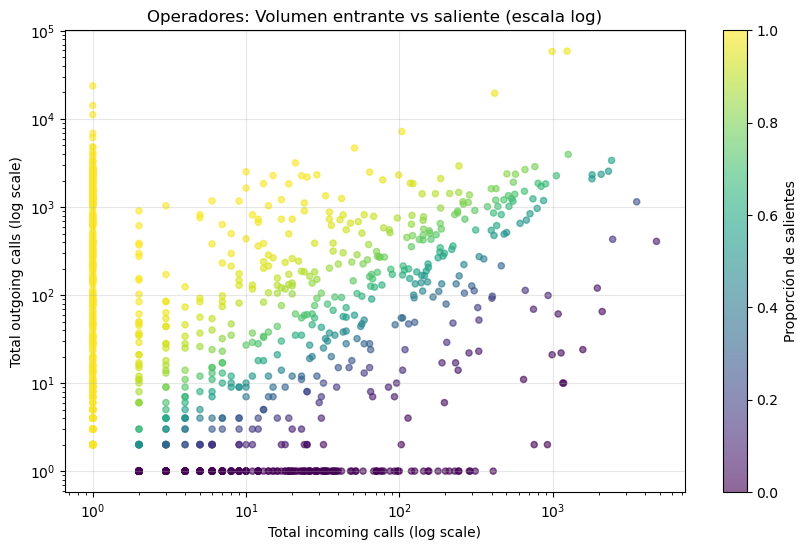

In [22]:
# Añadir columna de proporción de salientes para colorear
metrics['prop_outgoing'] = metrics['total_outgoing_calls'] / (metrics['total_incoming_calls'] + metrics['total_outgoing_calls'])
metrics['prop_outgoing'] = metrics['prop_outgoing'].fillna(0)  # si no hay llamadas, proporción 0

# Scatter plot de volumen entrante vs saliente con escala logarítmica y color por proporción de salientes para observar tendencias y posibles clusters de operadores según su volumen y balance entre entrantes y salientes.
plt.figure(figsize=(10, 6))
sc = plt.scatter(metrics['total_incoming_calls'] + 1,  # +1 para evitar log(0)
                 metrics['total_outgoing_calls'] + 1,
                 c=metrics['prop_outgoing'], cmap='viridis', alpha=0.6, s=20)
plt.xscale('log')
plt.yscale('log')
plt.colorbar(sc, label='Proporción de salientes')
plt.xlabel('Total incoming calls (log scale)')
plt.ylabel('Total outgoing calls (log scale)')
plt.title('Operadores: Volumen entrante vs saliente (escala log)')
plt.grid(True, alpha=0.3)
plt.show()

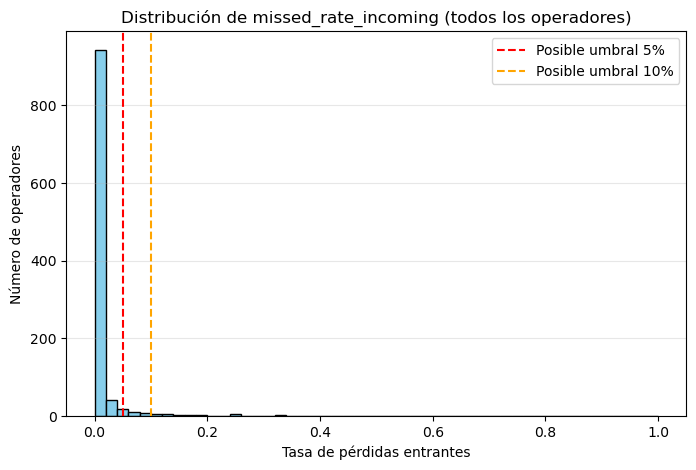

In [23]:
# histograma de la tasa de pérdidas de llamadas entrantes considerando la totalidad de los operadores (incluyendo aquellos sin llamadas entrantes, cuyo valor fue imputado a 0).

plt.figure(figsize=(8, 5))
plt.hist(metrics['missed_rate_incoming'], bins=50, edgecolor='black', color='skyblue')
plt.axvline(x=0.05, color='red', linestyle='--', label='Posible umbral 5%')
plt.axvline(x=0.1, color='orange', linestyle='--', label='Posible umbral 10%')
plt.xlabel('Tasa de pérdidas entrantes')
plt.ylabel('Número de operadores')
plt.title('Distribución de missed_rate_incoming (todos los operadores)')
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.show()

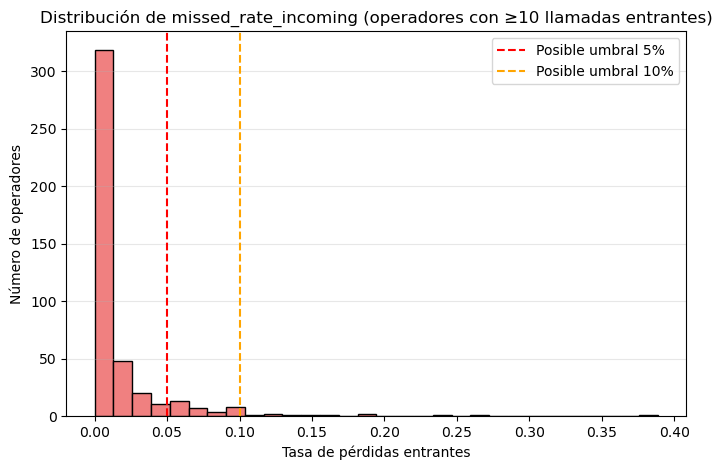

In [24]:
# Se filtra el DataFrame para quedarse con operadores que tengancal menos 10 llamadas entrantes reales (total_incoming_calls >= 10).
mask_incoming = metrics['total_incoming_calls'] >= 10

# Se genera el histograma de la tasa de pérdidas entrantes.
plt.figure(figsize=(8, 5))
plt.hist(metrics.loc[mask_incoming, 'missed_rate_incoming'], bins=30, edgecolor='black', color='lightcoral')
plt.axvline(x=0.05, color='red', linestyle='--', label='Posible umbral 5%')
plt.axvline(x=0.1, color='orange', linestyle='--', label='Posible umbral 10%')
plt.xlabel('Tasa de pérdidas entrantes')
plt.ylabel('Número de operadores')
plt.title('Distribución de missed_rate_incoming (operadores con ≥10 llamadas entrantes)')
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.show()

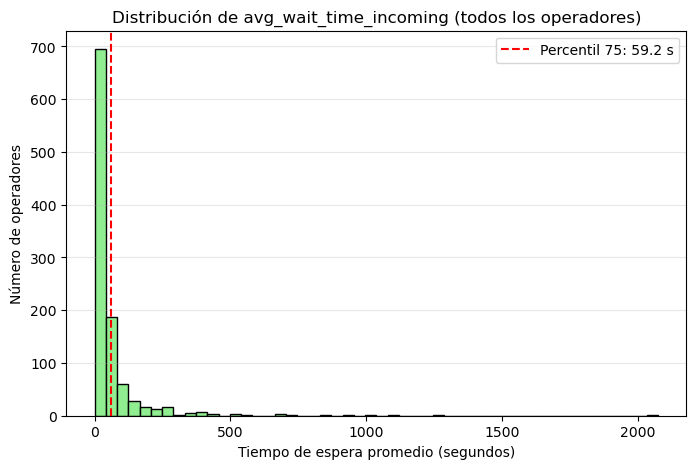

In [25]:
# Se genera el histograma del tiempo de espera promedio en llamadas entrantes para todos los operadores (los que no tienen llamadas entrantes tienen valor 0).

plt.figure(figsize=(8, 5))
plt.hist(metrics['avg_wait_time_incoming'], bins=50, edgecolor='black', color='lightgreen')
plt.axvline(x=metrics['avg_wait_time_incoming'].quantile(0.75), color='red', linestyle='--', label=f"Percentil 75: {metrics['avg_wait_time_incoming'].quantile(0.75):.1f} s")
plt.xlabel('Tiempo de espera promedio (segundos)')
plt.ylabel('Número de operadores')
plt.title('Distribución de avg_wait_time_incoming (todos los operadores)')
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.show()

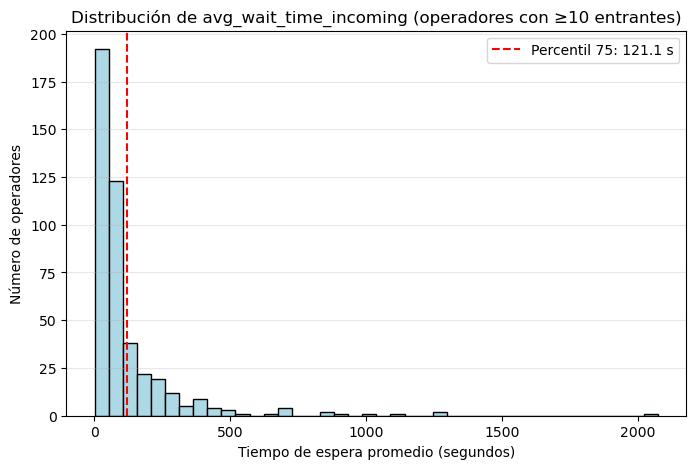

In [26]:
# Se filtra por operadores con al menos 10 llamadas entrantes
mask_incoming = metrics['total_incoming_calls'] >= 10

# Se genera el histograma del tiempo de espera promedio.
plt.figure(figsize=(8, 5))
plt.hist(metrics.loc[mask_incoming, 'avg_wait_time_incoming'], bins=40, edgecolor='black', color='lightblue')
plt.axvline(x=metrics.loc[mask_incoming, 'avg_wait_time_incoming'].quantile(0.75), color='red', linestyle='--', label=f"Percentil 75: {metrics.loc[mask_incoming, 'avg_wait_time_incoming'].quantile(0.75):.1f} s")
plt.xlabel('Tiempo de espera promedio (segundos)')
plt.ylabel('Número de operadores')
plt.title('Distribución de avg_wait_time_incoming (operadores con ≥10 entrantes)')
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.show()

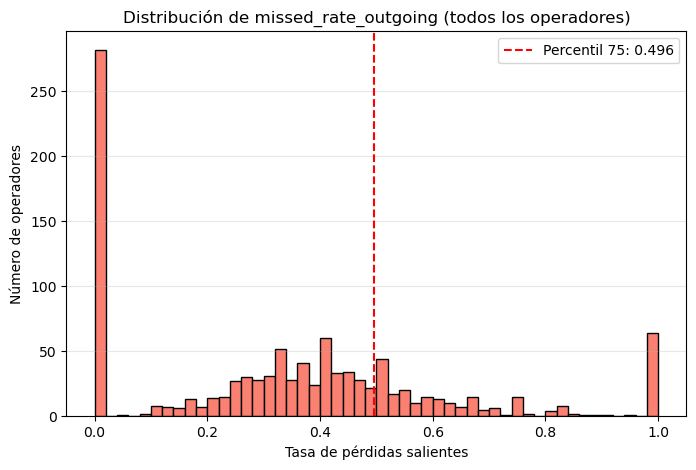

In [27]:
# Se genera el histograma de la tasa de pérdidas de llamadas salientes para el total de operadores.
plt.figure(figsize=(8, 5))
plt.hist(metrics['missed_rate_outgoing'], bins=50, edgecolor='black', color='salmon')
plt.axvline(x=metrics['missed_rate_outgoing'].quantile(0.75), color='red', linestyle='--', label=f"Percentil 75: {metrics['missed_rate_outgoing'].quantile(0.75):.3f}")
plt.xlabel('Tasa de pérdidas salientes')
plt.ylabel('Número de operadores')
plt.title('Distribución de missed_rate_outgoing (todos los operadores)')
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.show()

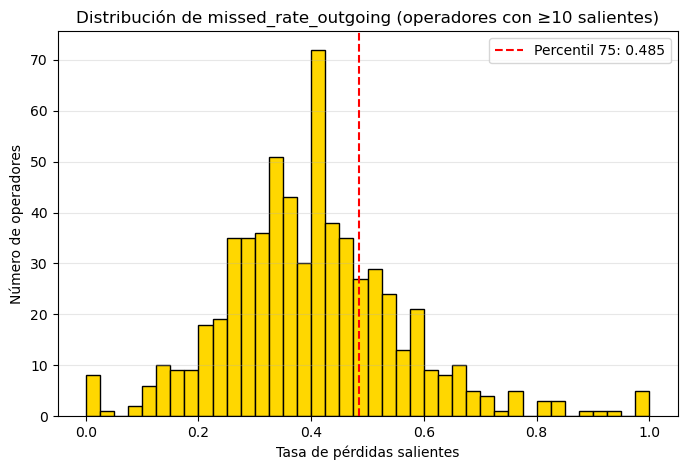

In [28]:
# Se filtra por operadores con al menos 10 llamadas salientes
mask_outgoing = metrics['total_outgoing_calls'] >= 10

# se genera el histograma de la tasa de pérdidas salientes.
plt.figure(figsize=(8, 5))
plt.hist(metrics.loc[mask_outgoing, 'missed_rate_outgoing'], bins=40, edgecolor='black', color='gold')
plt.axvline(x=metrics.loc[mask_outgoing, 'missed_rate_outgoing'].quantile(0.75), color='red', linestyle='--', label=f"Percentil 75: {metrics.loc[mask_outgoing, 'missed_rate_outgoing'].quantile(0.75):.3f}")
plt.xlabel('Tasa de pérdidas salientes')
plt.ylabel('Número de operadores')
plt.title('Distribución de missed_rate_outgoing (operadores con ≥10 salientes)')
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.show()

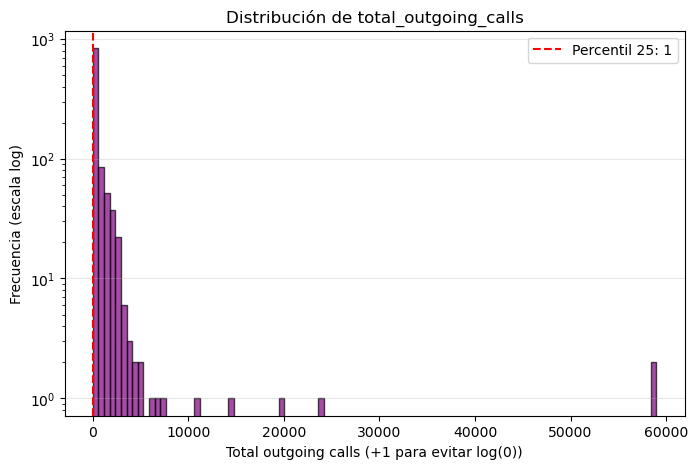

In [29]:
# Se genera un histograma del volumen de llamadas salientes. Debido a la alta asimetría, se utiliza escala logarítmica en el eje Y.

plt.figure(figsize=(8, 5))
plt.hist(metrics['total_outgoing_calls'] + 1, bins=100, edgecolor='black', color='purple', alpha=0.7)
plt.axvline(x=metrics['total_outgoing_calls'].quantile(0.25) + 1, color='red', linestyle='--', label=f"Percentil 25: {metrics['total_outgoing_calls'].quantile(0.25):.0f}") # Se añade una línea vertical en el percentil 25.
plt.yscale('log')
plt.xlabel('Total outgoing calls (+1 para evitar log(0))')
plt.ylabel('Frecuencia (escala log)')
plt.title('Distribución de total_outgoing_calls')
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.show()

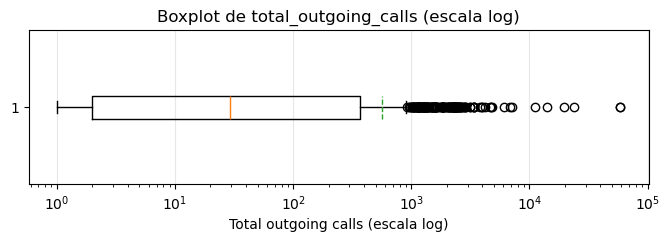

In [30]:
# Boxplot con escala logarítmica en X, de lo contrario no sería útil.
plt.figure(figsize=(8, 2))
plt.boxplot(metrics['total_outgoing_calls'] + 1, vert=False, showmeans=True, meanline=True)
plt.xscale('log')
plt.xlabel('Total outgoing calls (escala log)')
plt.title('Boxplot de total_outgoing_calls (escala log)')
plt.grid(axis='x', alpha=0.3)
plt.show()

### Conclusiones preliminares partir del DataFrame metrics

**Perfiles de operador (según proporción de salientes)**
Existen tres grupos claros:
- Solo receptores: prácticamente cero llamadas salientes (color morado en scatter).
- Solo emisores: prácticamente cero llamadas entrantes (color amarillo).
- Mixtos: volúmenes equilibrados o con predominio de un sentido.
 _Por tanto, cualquier penalización por bajo volumen saliente debe aplicarse solo a operadores que tengan una proporción significativa de llamadas salientes (por ejemplo, prop_outgoing > 0.2)._

**Tasa de pérdidas en llamadas entrantes (missed_rate_incoming)**
- El 88% de los operadores tiene tasa = 0 (no pierden ninguna llamada entrante). Esto implica que cualquier pérdida entrante es atípica, por lo que un umbral bajo (por ejemplo, 5%) es suficiente para identificar a los operadores problemáticos.
- Solo una minoría supera el 5% de pérdidas, por lo que es un buen umbral para puntuar en el ranking.

**Tiempo de espera promedio en llamadas entrantes (avg_wait_time_incoming)**
- Distribución muy sesgada a la derecha con una larga cola, lo que indica que algunos operadores tienen tiempos de espera extremadamente altos (más de 2000 segundos).
- Para operadores con ≥10 llamadas entrantes (actividad mínima), el percentil 75 es 121 segundos (≈2 minutos), lo que puede ser un buen umbral.
- Existen valores extremos (>2000 segundos) en muy pocos operadores, es necesario que el ranking los detecte.

**Tasa de pérdidas en llamadas salientes (missed_rate_outgoing)**
- Sin filtrar: distribución bimodal con picos en 0 y 1, lo que significa que hay usuarios que no hacen llamadas salientes y tienen 0, así como que hay algunos que pierden todas.
- Al filtrar por ≥10 llamadas salientes, la distribución se aproxima a una normal centrada en 0.4 (40% de pérdidas). Esto indica que la alta tasa de pérdidas en salientes es un problema extendido, no limitado a unos pocos operadores.
- El percentil 75 (con filtro) es 0.49 (49% de pérdidas), lo que puede ser un umbral adecuado para el ranking.

**Volumen de llamadas por operador:**
_Llamadas entrantes:_
- El 25% de los operadores tiene 0 llamadas entrantes, esto sugiere que una parte significativa de los operadores no recibe llamadas entrantes, lo que refuerza la necesidad de analizar perfiles por separado.
- La mediana de 5 llamadas es baja; esto será relevante al definir un umbral mínimo de actividad para calcular la tasa de pérdidas.
- La Media es 88 pero está inflada por pocos operadores con mucho volumen, máximo 4766, para un análisis más robusto se podría filtrar a operadores con al menos, por ejemplo, 10 llamadas entrantes.

_Llamadas salientes:_
- El 25% de los operadores hace 1 o menos llamadas salientes, esto confirma la existencia de operadores con muy baja actividad en salidas, que deberán ser tratados según su rol.
- La mediana es 28 llamadas, lo que parece poco para un periodo de 4 meses.
- La media es de 564. Una media muy superior a la mediana indica una fuerte asimetría, con unos pocos operadores realizando volúmenes extremadamente altos.


**Siguientes pasos:** Se analizará la proporción de llamadas salientes con duración cero, se definirán los umbrales definitivos y se construirá el sistema de ranking.

## Paso 3 creacion del score de ineficacia

Estadísticas de zero_outgoing_ratio (todos los operadores):
count    1055.000000
mean        0.342559
std         0.280557
min         0.000000
25%         0.000000
50%         0.345145
75%         0.496201
max         1.000000
Name: zero_outgoing_ratio, dtype: float64


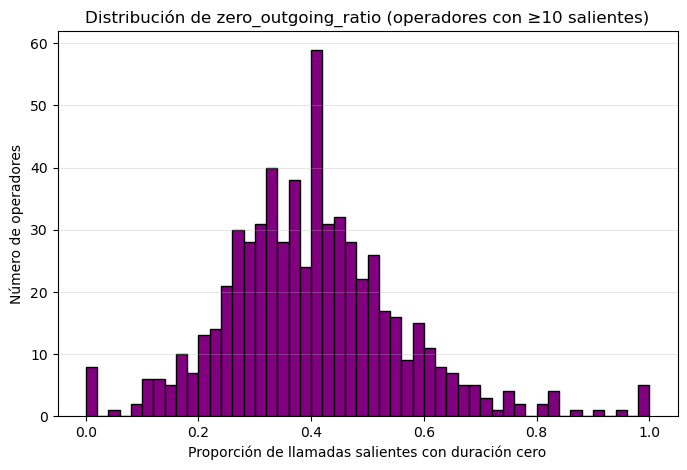

In [31]:
# Se Filtra las llamadas salientes externas
out_ext = operators_clean[
    (operators_clean['direction'] == 'out') & 
    (operators_clean['internal'] == False)
].copy()

# Se crea una columna auxiliar: ponderación de llamadas con duración cero
out_ext['zero_ponderado'] = (out_ext['call_duration'] == 0) * out_ext['calls_count']

# se agrupar por operador y sumar
zero_out = out_ext.groupby('operator_id')['zero_ponderado'].sum().reset_index(name='total_zero_outgoing')

# Se hacer merge con metrics 
metrics = metrics.merge(zero_out, on='operator_id', how='left').fillna(0)

#  Se calcula la proporción de llamadas salientes con duración cero sobre el total de llamadas salientes para cada operador.
metrics['zero_outgoing_ratio'] = metrics['total_zero_outgoing'] / metrics['total_outgoing_calls']
metrics['zero_outgoing_ratio'] = metrics['zero_outgoing_ratio'].fillna(0)

# Se muestran estadísticas descriptivas de la nueva métrica calculada.
print("Estadísticas de zero_outgoing_ratio (todos los operadores):")
print(metrics['zero_outgoing_ratio'].describe())

# 7. Histograma para operadores con al menos 10 salientes
mask_out10 = metrics['total_outgoing_calls'] >= 10

plt.figure(figsize=(8,5))
plt.hist(metrics.loc[mask_out10, 'zero_outgoing_ratio'], bins=50, edgecolor='black', color='purple')
plt.xlabel('Proporción de llamadas salientes con duración cero')
plt.ylabel('Número de operadores')
plt.title('Distribución de zero_outgoing_ratio (operadores con ≥10 salientes)')
plt.grid(axis='y', alpha=0.3)
plt.show()

## Definición de umbrales de ineficiencia

A partir del análisis exploratorio y las distribuciones observadas en las métricas por operador (siempre ponderadas por `calls_count`), se establecieron los siguientes criterios para identificar comportamientos ineficaces. Cada criterio otorga 1 punto. Un operador con puntuación ≥ 3 se considera ineficaz grave.

1. Alta tasa de llamadas entrantes perdidas (`missed_rate_incoming`)
- **Umbral:** > 0.05 (5%)
- **Justificación:** El 88% de los operadores tiene tasa 0. Solo una pequeña cola (≈5-10%) supera el 5%. El percentil 75 es 0, por lo que se eligió un valor de negocio bajo para capturar los casos realmente problemáticos.

2. Alto tiempo de espera en llamadas entrantes (`avg_wait_time_incoming`)
- **Umbral:** > 121 segundos
- **Justificación:** Corresponde al percentil 75 de los operadores con al menos 10 llamadas entrantes (actividad mínima). Representa un nivel de espera anormalmente alto.

3. Bajo volumen de llamadas salientes (`total_outgoing_calls`)
- **Umbral:** < 28 llamadas **y** `prop_outgoing > 0.2`
- **Justificación:** 
  - El valor 28 es la mediana de `total_outgoing_calls`. Penaliza a la mitad de los operadores, pero se aplica **solo** a aquellos cuya actividad incluye al menos un 20% de llamadas salientes (para no castigar a receptores puros).
  - Se eligió la mediana porque es un punto de corte estadístico objetivo y, combinado con otros criterios, evita falsos positivos.

4. Alta tasa de llamadas salientes perdidas (`missed_rate_outgoing`)
- **Umbral:** > 0.49 (49%)
- **Justificación:** Es el percentil 75 de los operadores con al menos 10 llamadas salientes. El 25% de los operadores activos supera esta tasa, indicando un problema generalizado de pérdidas en salientes.

5. Alta proporción de llamadas salientes con duración cero (`zero_outgoing_ratio`)
- **Umbral:** > 0.8 (80%)
- **Justificación:** La distribución de esta métrica es aproximadamente normal centrada en 0.4. Solo una pequeña cola (≈5% de operadores) supera el 80%. Este umbral captura comportamientos extremadamente anómalos (llamadas que nunca conectan o se cortan inmediatamente), sin penalizar a la mayoría.

### Nota sobre operadores con baja actividad
No se excluye a ningún operador del ranking. Aquellos con muy pocas llamadas obtendrán puntuaciones bajas (por ejemplo, `missed_rate_incoming = 0`, `avg_wait_time_incoming = 0`, etc.). La baja actividad en sí misma es una alerta que puede detectarse mediante la regla 3 si el operador tiene `prop_outgoing > 0.2` y menos de 28 salientes.

In [32]:
# Se Calcula la proporción de llamadas salientes sobre el total (para aplicar la regla 3 solo a quienes tienen actividad de salida)
metrics['prop_outgoing'] = metrics['total_outgoing_calls'] / (metrics['total_incoming_calls'] + metrics['total_outgoing_calls'])
metrics['prop_outgoing'] = metrics['prop_outgoing'].fillna(0)  # Si no hay llamadas, proporción 0

# Se aplican las 5 reglas (cada una aporta 1 punto)
metrics['rule1'] = (metrics['missed_rate_incoming'] > 0.05).astype(int)
metrics['rule2'] = (metrics['avg_wait_time_incoming'] > 121).astype(int)
metrics['rule3'] = ((metrics['total_outgoing_calls'] < 28) & (metrics['prop_outgoing'] > 0.2)).astype(int)
metrics['rule4'] = (metrics['missed_rate_outgoing'] > 0.49).astype(int)
metrics['rule5'] = (metrics['zero_outgoing_ratio'] > 0.8).astype(int)

# 3. Sumar los puntos para obtener el score total
metrics['inefficiency_score'] = metrics[['rule1', 'rule2', 'rule3', 'rule4', 'rule5']].sum(axis=1)

# 4. Ver distribución de puntuaciones
print("Distribución de inefficiency_score (0 a 5):")
print(metrics['inefficiency_score'].value_counts().sort_index())
print(f"Proporción de operadores con score >= 3: {(metrics['inefficiency_score'] >= 3).mean() * 100:.2f}%")

Distribución de inefficiency_score (0 a 5):
inefficiency_score
0    530
1    351
2    104
3     68
4      2
Name: count, dtype: int64
Proporción de operadores con score >= 3: 6.64%


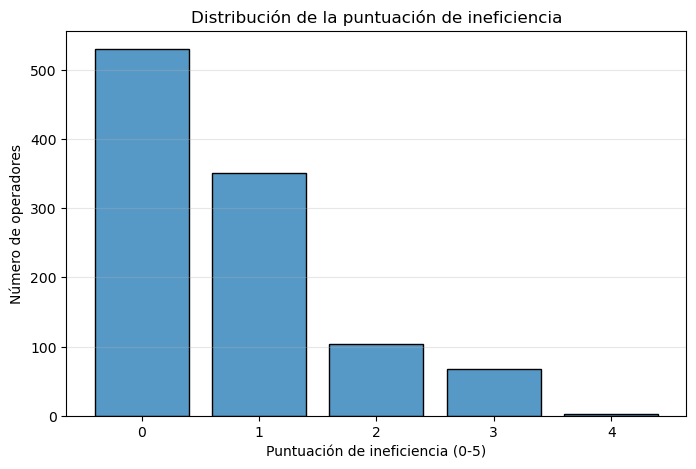

In [33]:
# Histograma de puntuaciones
plt.figure(figsize=(8,5))
sns.histplot(metrics['inefficiency_score'], bins=6, discrete=True, shrink=0.8)
plt.xlabel('Puntuación de ineficiencia (0-5)')
plt.ylabel('Número de operadores')
plt.title('Distribución de la puntuación de ineficiencia')
plt.grid(axis='y', alpha=0.3)
plt.show()


In [34]:

# Se crea DF con resumen ejecutivo para cada operador, incluyendo las métricas clave y la puntuación total.
# Se crean columnas adicionales para reporte ejecutivo (porcentajes)

metrics['missed_rate_incoming_pct'] = metrics['missed_rate_incoming'] * 100
metrics['missed_rate_outgoing_pct'] = metrics['missed_rate_outgoing'] * 100
metrics['zero_outgoing_ratio_pct'] = metrics['zero_outgoing_ratio'] * 100
metrics['avg_wait_time_incoming_sec'] = metrics['avg_wait_time_incoming']

# Se ordenan todos los operadores por score descendente
# -------------------------------------------------------------------
ranking_general = metrics.sort_values('inefficiency_score', ascending=False).copy()

# Seleccionar columnas relevantes para la toma de decisiones
columnas_decision = [
    'operator_id',
    'inefficiency_score',
    'rule1', 'rule2', 'rule3', 'rule4', 'rule5',
    'total_incoming_calls',
    'missed_rate_incoming_pct',
    'avg_wait_time_incoming_sec',
    'total_outgoing_calls',
    'missed_rate_outgoing_pct',
    'zero_outgoing_ratio_pct',
    'prop_outgoing'
]

ranking_general = ranking_general[columnas_decision]

# Se crea un subconjunto de operadores ineficaces (score >= 3)
# -------------------------------------------------------------------
operadores_ineficaces = ranking_general[ranking_general['inefficiency_score'] >= 3].copy()

# Se muestra resumen se guardan archivos
# -------------------------------------------------------------------
print("Resumen del ranking general:")
print(f"Total operadores: {len(ranking_general)}")
print(f"Distribución de puntuaciones:\n{ranking_general['inefficiency_score'].value_counts().sort_index()}")
print(f"\nOperadores ineficaces (score >= 3): {len(operadores_ineficaces)} ({len(operadores_ineficaces)/len(ranking_general)*100:.1f}%)")

# Guardar ambos DataFrames como CSV
ranking_general.to_csv('data/processed/ranking_operadores_completo.csv', index=False)
operadores_ineficaces.to_csv('data/processed/operadores_ineficaces_score_3_o_mas.csv', index=False)

print("\nArchivos guardados:")
print("- data/processed/ranking_operadores_completo.csv (todos los operadores ordenados por puntuación)")
print("- data/processed/operadores_ineficaces_score_3_o_mas.csv (solo puntuación >= 3)")

# se muestran las primeras filas de los ineficaces para vista rápida
print("\nPrimeros 5 operadores ineficaces (mayor puntuación):")
print(operadores_ineficaces.head().to_string(index=False))



Resumen del ranking general:
Total operadores: 1055
Distribución de puntuaciones:
inefficiency_score
0    530
1    351
2    104
3     68
4      2
Name: count, dtype: int64

Operadores ineficaces (score >= 3): 70 (6.6%)

Archivos guardados:
- data/processed/ranking_operadores_completo.csv (todos los operadores ordenados por puntuación)
- data/processed/operadores_ineficaces_score_3_o_mas.csv (solo puntuación >= 3)

Primeros 5 operadores ineficaces (mayor puntuación):
operator_id  inefficiency_score  rule1  rule2  rule3  rule4  rule5  total_incoming_calls  missed_rate_incoming_pct  avg_wait_time_incoming_sec  total_outgoing_calls  missed_rate_outgoing_pct  zero_outgoing_ratio_pct  prop_outgoing
     888406                   4      1      0      1      1      1                   9.0                 11.111111                   43.666667                   6.0                 83.333333                83.333333       0.400000
     918888                   4      1      0      1      1      1 

## Resultados del ranking de ineficiencia

Una vez aplicados los cinco criterios de ineficiencia a los 1055 operadores, se obtuvieron las siguientes puntuaciones (rango 0 a 5):

| Puntuación | Número de operadores | Porcentaje |
|------------|----------------------|-------------|
| 0          | 530                  | 50.2%       |
| 1          | 351                  | 33.3%       |
| 2          | 104                  | 9.9%        |
| 3          | 68                   | 6.4%        |
| 4          | 2                    | 0.2%        |
| 5          | 0                    | 0.0%        |

### Hallazgos clave del ranking

- **La mitad de los operadores (50.2%) no presenta ningún indicador de ineficiencia** (puntuación 0).  
- **Un 6.6% del total (70 operadores) alcanza una puntuación ≥ 3**, considerada como ineficacia grave.  
- **Solo 2 operadores obtuvieron la puntuación máxima observada (4)**, ninguno llegó a 5.  
- Los operadores con puntuación 3 o 4 presentan combinaciones de alta pérdida saliente, alta duración cero en salientes y bajo volumen saliente. Por ejemplo, los dos operadores con puntuación 4 (IDs 888406 y 918888) tienen `missed_rate_outgoing_pct` del 83% y 100% respectivamente, y `zero_outgoing_ratio_pct` también muy altos (83% y 100%).  
- El tiempo de espera en entrantes no es un factor común entre los ineficaces graves: ninguno de los primeros cinco superó los 121 segundos.  
- La distribución de puntuaciones es fuertemente asimétrica hacia la izquierda (mayoría en 0 y 1), lo que indica que los problemas de ineficiencia están concentrados en una minoría de operadores.

Se gerenaron archivos para la toma de desiciones ejecutivas

- `ranking_operadores_completo.csv`: todos los operadores ordenados por puntuación descendente, con métricas clave.  
- `operadores_ineficaces_score_3_o_mas.csv`: lista detallada de los 70 operadores con puntuación ≥ 3.

## Paso 4: comporbación estadistica de los resultados

UUna vez realizado el ranking, se procede a comprobar si el grupo de operadores altamente ineficaces (score ≥ 3) es realmente distinto al resto. También se evalúa la relación entre ciertas métricas para comprobar que el score tenga un impacto real. A continuación se desglosa cada prueba y sus implicaciones:

1. Primera prueba: Comparar missed_rate_outgoing entre ineficaces (score ≥ 3) y el resto
**Hipótesis:**
_H0:_ No hay diferencia en la mediana de missed_rate_outgoing entre operadores ineficaces (score ≥ 3) y el resto.

_H1:_ Los operadores ineficaces tienen mayor mediana de missed_rate_outgoing.

Prueba: Mann-Whitney U (no paramétrica, para dos muestras independientes).

2. Segunda prueba: Correlación entre missed_rate_outgoing y zero_outgoing_ratio
**Hipótesis:**
_H0:_ No existe correlación entre la tasa de pérdidas salientes y la proporción de llamadas salientes con duración cero.

_H1:_ Existe correlación positiva (quienes pierden más también tienen más llamadas de duración cero).

Prueba: Coeficiente de correlación de Spearman (no paramétrico, para relaciones monótonas).

3. Tercera prueba: Comparar avg_wait_time_incoming entre operadores con alta pérdida entrante (rule1=1) y el resto
**Hipótesis:**
_H0:_ No hay diferencia en la mediana de avg_wait_time_incoming entre operadores con alta tasa de pérdidas entrantes (rule1=1) y el resto.

_H1:_ Los operadores con alta pérdida entrante tienen mayor tiempo de espera.

Prueba: Mann-Whitney U (alternativa 'greater').

In [35]:
from scipy.stats import mannwhitneyu

# Separar los dos grupos
ineficaces = metrics[metrics['inefficiency_score'] >= 3]['missed_rate_outgoing']
no_ineficaces = metrics[metrics['inefficiency_score'] < 3]['missed_rate_outgoing']

# Realizar la prueba
stat, p_value = mannwhitneyu(ineficaces, no_ineficaces, alternative='greater')

print(f"U estadístico: {stat}")
print(f"p-valor: {p_value}")
if p_value < 0.05:
    print("Rechazamos H0: los ineficaces tienen mayor missed_rate_outgoing (estadísticamente significativo).")
else:
    print("No rechazamos H0: no hay evidencia suficiente de diferencia.")

U estadístico: 67418.0
p-valor: 7.32387466819584e-42
Rechazamos H0: los ineficaces tienen mayor missed_rate_outgoing (estadísticamente significativo).


In [36]:
from scipy.stats import spearmanr

# Calcular correlación de Spearman entre las dos métricas
corr, p_value = spearmanr(metrics['missed_rate_outgoing'], metrics['zero_outgoing_ratio'])

print(f"Coeficiente de Spearman: {corr:.4f}")
print(f"p-valor: {p_value}")
if p_value < 0.05:
    if corr > 0:
        print("Correlación positiva significativa (rechazamos H0).")
    else:
        print("Correlación negativa significativa (rechazamos H0).")
else:
    print("No rechazamos H0: no hay evidencia de correlación.")

Coeficiente de Spearman: 0.9996
p-valor: 0.0
Correlación positiva significativa (rechazamos H0).


El coeficiente de Spearman obtenido es 0.9996 (cercano a 1) y el p-valor es 0.0. Esto indica una correlación positiva prácticamente perfecta entre la tasa de llamadas salientes perdidas y la proporción de llamadas salientes con duración cero. En este conjunto de datos, las llamadas salientes perdidas son casi siempre llamadas de duración cero, y viceversa. Este hallazgo es consistente con la hipótesis de que muchos operadores realizan "llamadas fantasma" (intentos de llamada que no llegan a concretar conversación), lo que puede reflejar ineficacia o malas prácticas.

In [37]:
alta_perdida = metrics[metrics['rule1'] == 1]['avg_wait_time_incoming']
resto = metrics[metrics['rule1'] == 0]['avg_wait_time_incoming']

stat, p_value = mannwhitneyu(alta_perdida, resto, alternative='greater')

print(f"U estadístico: {stat}")
print(f"p-valor: {p_value}")
if p_value < 0.05:
    print("Rechazamos H0: los que tienen alta pérdida entrante tienen mayor tiempo de espera.")
else:
    print("No rechazamos H0: no hay evidencia suficiente.")

U estadístico: 39277.0
p-valor: 4.20511585214208e-05
Rechazamos H0: los que tienen alta pérdida entrante tienen mayor tiempo de espera.


### Resultados de las pruebas 

**Prueba 1 (diferencia en `missed_rate_outgoing`):**  
Los operadores con score ≥ 3 (ineficaces) tienen una tasa de pérdidas salientes significativamente mayor que aquellos con score < 3. Esto confirma que el score capta adecuadamente esta dimensión.

**Prueba 2 (correlación entre `missed_rate_outgoing` y `zero_outgoing_ratio`):**  
Existe una correlación prácticamente perfecta (ρ = 0.9996). Esto significa que, en los operadores con alta puntuación, las llamadas perdidas son casi siempre de duración cero, lo que refuerza la coherencia de las reglas 4 y 5 del score.

**Prueba 3 (diferencia en `avg_wait_time_incoming`):**  
Los operadores que activaron la regla 1 (alta pérdida entrante) tienen tiempos de espera significativamente mayores que el resto. Esto valida que la regla 1 del score se asocia a otra métrica de ineficiencia (el tiempo de espera).

# Paso 5: Conclusiones y recomendaciones

### Resumen de hallazgos clave

- **Ponderación obligatoria:** Al ponderar por `calls_count`, el volumen real de llamadas salientes supera el 90% del tráfico, mientras que las entrantes caen por debajo del 10%. La tasa global de llamadas perdidas asciende a más del 50%, muy por encima del 34% que sugería el análisis por filas, por lo que hubo que usar la ponderación para el análisis y no perder de vista ese alto número de llamadas.
- **Distribuciones asimétricas:** La mayoría de los operadores tiene muy pocas llamadas (entrantes y salientes), pero unos pocos realizan volúmenes extremadamente altos (outliers), por lo que el score buscó crear métricas que consideraran esta asimetria.
- **Pérdidas en salientes:** Es un problema generalizado: la mediana de `missed_rate_outgoing` es 34.5% y el percentil 75 alcanza 49%. Además, existe una correlación casi perfecta (ρ=0.9996) con la proporción de llamadas de duración cero, lo que sugiere que muchas pérdidas corresponden a “llamadas fantasma” (marcar sin conversación).
- **Pérdidas en entrantes:** Son muy poco frecuentes (88% de operadores con 0% pérdidas). Solo una minoría supera el 5%, por lo que cualquier pérdida entrante es atípica.
- **Tiempo de espera en entrantes:** Moderado en general, pero el 25% de los operadores con actividad (≥10 llamadas entrantes) supera los 121 segundos (≈2 minutos), y existen valores extremos (>2000 s), el score creado también muestra estos operadores.
- **Ranking de ineficiencia:** Se identificaron **70 operadores ineficaces graves** (puntuación ≥ 3), que representan el 6.6% del total. Solo 2 operadores alcanzaron puntuación 4 (máxima observada). La distribución de puntuaciones es fuertemente asimétrica (50% con 0 puntos), lo que es una buena noticia en general, pero aun así existen agunos operadores con algun punto de ineficacia.

### Perfil del operador ineficaz (score ≥ 3):

- Alta tasa de pérdidas salientes (típicamente >50%) y alta proporción de llamadas con duración cero (>80% en los casos extremos).
- Bajo volumen de llamadas salientes (menos de 28 en 4 meses), combinado con una proporción de salientes significativa (`prop_outgoing > 0.2`), lo que indica baja productividad en su rol.
- En algunos casos, también presentan pérdidas entrantes (>5%) y tiempos de espera elevados, aunque estas dimensiones son menos frecuentes.
- Los dos operadores con puntuación 4 (IDs 888406 y 918888) concentran las peores prácticas: pérdidas salientes ≥83%, duración cero ≥83% y volumen saliente muy bajo (≤6 llamadas).

### Validación estadística

Las tres hipótesis planteadas se confirmaron con un nivel de significación α=0.05:
- Los operadores ineficaces tienen mayor `missed_rate_outgoing` que el resto (Mann-Whitney, p≈0).
- Existe correlación positiva prácticamente perfecta entre `missed_rate_outgoing` y `zero_outgoing_ratio` (Spearman, ρ=0.9996, p=0).
- Los operadores con alta pérdida entrante (regla 1) tienen mayor `avg_wait_time_incoming` (Mann-Whitney, p≈4.2e-5).

Estos resultados respaldan que el sistema de score captura consistentemente a los operadores problemáticos y que las métricas elegidas están interrelacionadas.

### Recomendaciones prácticas

1. **Revisión prioritaria:** Los 70 operadores con score ≥ 3 deben ser evaluados por supervisión. Especial atención a los 2 con score 4 (IDs 888406 y 918888) por su comportamiento extremo.
2. **Investigación técnica:** Dada la correlación casi perfecta entre pérdidas salientes y duración cero, se recomienda auditar la red y los registros de llamadas para descartar fallos técnicos o configuraciones que generen “llamadas fantasma”. Si se confirma mala práctica, aplicar medidas correctivas.
3. **Reasignación de roles:** Los operadores con muy bajo volumen saliente pero que sí tienen responsabilidad de llamar (prop_outgoing > 0.2) podrían beneficiarse de coaching o de un cambio a funciones de recepción si su perfil es más adecuado.
4. **Monitoreo continuo:** Implementar el sistema de ranking de forma periódica (ej. mensual) para detectar tendencias y evaluar el impacto de las intervenciones.
5. **Limitaciones del estudio:** No se dispone de información sobre el rol real de cada operador (emisor, receptor o mixto), por lo que la penalización por bajo volumen saliente se aplicó mediante una heurística (`prop_outgoing > 0.2`). En futuras iteraciones, se recomienda contar con datos explícitos de funciones.

### Archivos generados
- `data/processed/operators_cleaned.csv` – DataFrame limpio de operadores (con `wait_time` y tipos corregidos).
- `data/processed/clients_cleaned.csv` – DataFrame limpio de clientes (fechas y categorías).
- `data/processed/metrics_operadores.csv` – DataFrame con métricas agregadas por operador (tasas de pérdidas, tiempos de espera, volúmenes, proporción de salientes, etc.), sin la puntuación de ranking.
- `data/processed/ranking_operadores_completo.csv` – todos los operadores ordenados por puntuación de ineficiencia.
- `data/processed/operadores_ineficaces_score_3_o_mas.csv` – lista detallada de los 70 operadores ineficaces graves.